In [13]:
import numpy as np

# Define dimensions
num_channels = 4  # Channels: 1, 2, 3, 4 (indices 0-3)
value_range = (0, 10)  # Values: 0 to 10 (11 values, indices 0-10)
z_range = (0, 48)  # z: 0 to 35 (36 values, indices 0-35)
y_range = (0, 343)  # y: 0 to 343 (344 values, indices 0-343)
x_range = (0, 680)  # x: 0 to 680 (681 values, indices 0-680)

# Calculate array dimensions
num_values = value_range[1] - value_range[0] + 1  # 11 values (0-10)
z_dim = z_range[1] - z_range[0] + 1  # 36 values (0-35)
y_dim = y_range[1] - y_range[0] + 1  # 344 values (0-343)
x_dim = x_range[1] - x_range[0] + 1  # 681 values (0-680)

# Calculate scaling factors
x_scale = x_dim / 172  # Old x_dim was 172
y_scale = y_dim / 87   # Old y_dim was 87

# Create 5D array initialized with zeros
# Shape: (channel, value, z, y, x)
data = np.zeros((num_channels, num_values, z_dim, y_dim, x_dim), dtype=np.int8)

# Generate random values for each (z, y, x) position
for i in range(0, 3):
    for z in range(z_dim):
        # Channel 0: x ranges scaled from original 38+20*i to 43+20*i
        for y in range(y_dim):
            x_start = max(0, int((38+20*i) * x_scale))
            x_end = min(x_dim, int((43+20*i) * x_scale))
            for x in range(x_start, x_end):
                random_value = np.random.randint(6, 11)
                data[0, random_value, z, y, x] = 1
        # Channel 1: y ranges scaled from original 18+20*i to 23+20*i
        y_start = max(0, int((18+20*i) * y_scale))
        y_end = min(y_dim, int((23+20*i) * y_scale))
        for y in range(y_start, y_end):
            for x in range(x_dim):
                random_value = np.random.randint(6, 11)
                data[1, random_value, z, y, x] = 1
        # Channel 2: diagonal lines with slope 1 (y = x + c)
        strip_width = int(3 * max(x_scale, y_scale))  # Scaled strip width
        c_values = [int(-60 * x_scale), 0]  # Scaled c values
        for c in c_values:
            for y in range(y_dim):
                for x in range(x_dim):
                    if abs(y - x - c) <= strip_width:
                        random_value = np.random.randint(6, 11)
                        data[2, random_value, z, y, x] = 1
        # Channel 3: diagonal lines with slope -1 (y = -x + d)
        strip_width = int(3 * max(x_scale, y_scale))  # Scaled strip width
        d_values = [int(60 * y_scale), int(120 * y_scale)]  # Scaled d values
        for d in d_values:
            for y in range(y_dim):
                for x in range(x_dim):
                    if abs(y + x - d) <= strip_width:
                        random_value = np.random.randint(6, 11)
                        data[3, random_value, z, y, x] = 1

print(f"Created 5D data array with shape: {data.shape}")
print(f"Dimensions breakdown:")
print(f"  - Channels: {num_channels} (1, 2, 3, 4)")
print(f"  - Values: {num_values} (0 to {value_range[1]})")
print(f"  - Z: {z_dim} (0 to {z_range[1]})")
print(f"  - Y: {y_dim} (0 to {y_range[1]})")
print(f"  - X: {x_dim} (0 to {x_range[1]})")
print(f"\nData type: {data.dtype}")
print(f"Total elements: {data.size:,}")
print(f"Memory size: {data.nbytes / 1024 / 1024:.2f} MB")

# Save the data
np.save('groundtruth.npy', data)
print(f"\n✓ 5D data saved to: groundtruth.npy")


Created 5D data array with shape: (4, 11, 49, 344, 681)
Dimensions breakdown:
  - Channels: 4 (1, 2, 3, 4)
  - Values: 11 (0 to 10)
  - Z: 49 (0 to 48)
  - Y: 344 (0 to 343)
  - X: 681 (0 to 680)

Data type: int8
Total elements: 505,073,184
Memory size: 481.68 MB

✓ 5D data saved to: groundtruth.npy


C:\Users\hosse\AppData\Local\Temp\ipykernel_59644\1887135946.py:12: RuntimeWarning:

invalid value encountered in divide



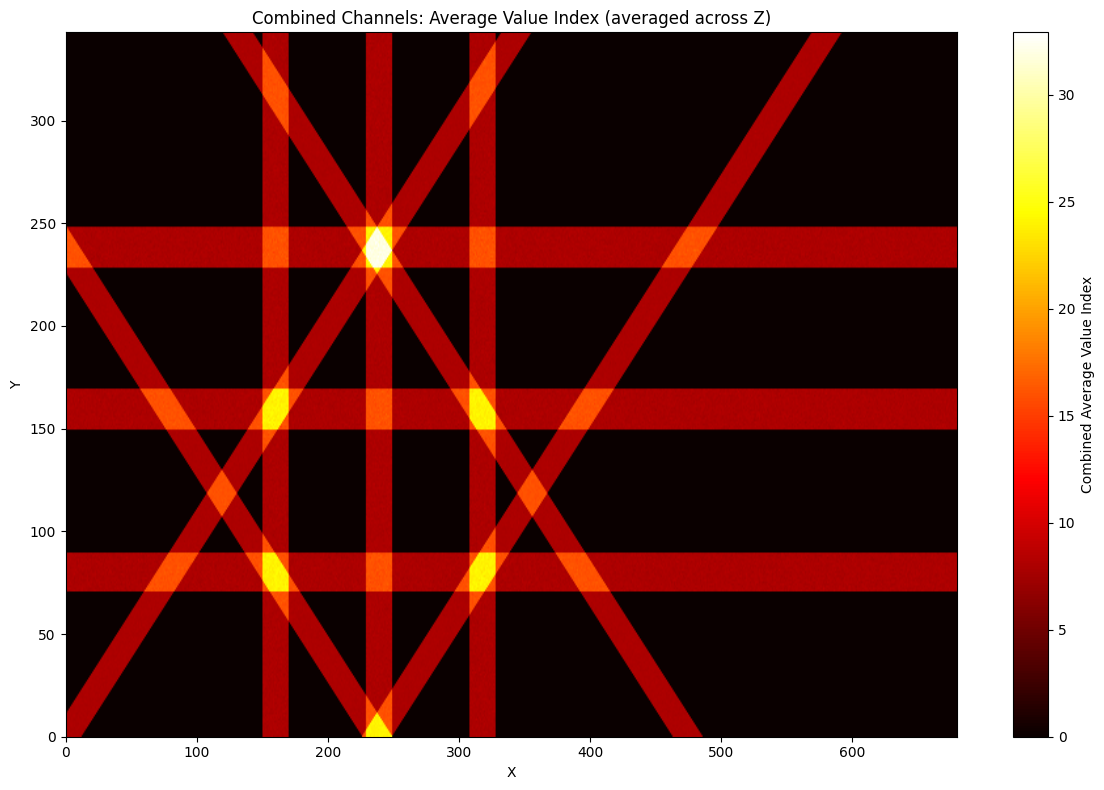


✓ Combined channels visualization
  Image shape: (344, 681)
  Value range: [0.00, 32.91]


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Load data
data = np.load('groundtruth.npy')
combined_image = np.zeros((y_dim, x_dim), dtype=np.float32)
for channel in range(4):
    channel_data = data[channel]  # Shape: (11, 12, 87, 172)
    value_indices = np.arange(11).reshape(-1, 1, 1, 1)  # Shape: (11, 1, 1, 1)
    weighted_sum = np.sum(value_indices * channel_data, axis=0)  # Shape: (12, 87, 172)
    total_sum = np.sum(channel_data, axis=0)  # Shape: (12, 87, 172)
    avg_value_index = np.where(total_sum > 0, weighted_sum / total_sum, 0)  # Shape: (12, 87, 172)
    avg_z = np.mean(avg_value_index, axis=0)  # Shape: (87, 172)
    combined_image += avg_z
# Plot combined image
plt.figure(figsize=(12, 8))
plt.imshow(combined_image, origin='lower', extent=[0, x_dim-1, 0, y_dim-1],
           aspect='auto', interpolation='bilinear', cmap='hot')
plt.colorbar(label='Combined Average Value Index')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Combined Channels: Average Value Index (averaged across Z)')
plt.xlim(0, x_dim-1)
plt.ylim(0, y_dim-1)
plt.tight_layout()
plt.show()

print(f"\n✓ Combined channels visualization")
print(f"  Image shape: {combined_image.shape}")
print(f"  Value range: [{combined_image.min():.2f}, {combined_image.max():.2f}]")


C:\Users\hosse\AppData\Local\Temp\ipykernel_59644\1277307529.py:29: RuntimeWarning:

invalid value encountered in divide



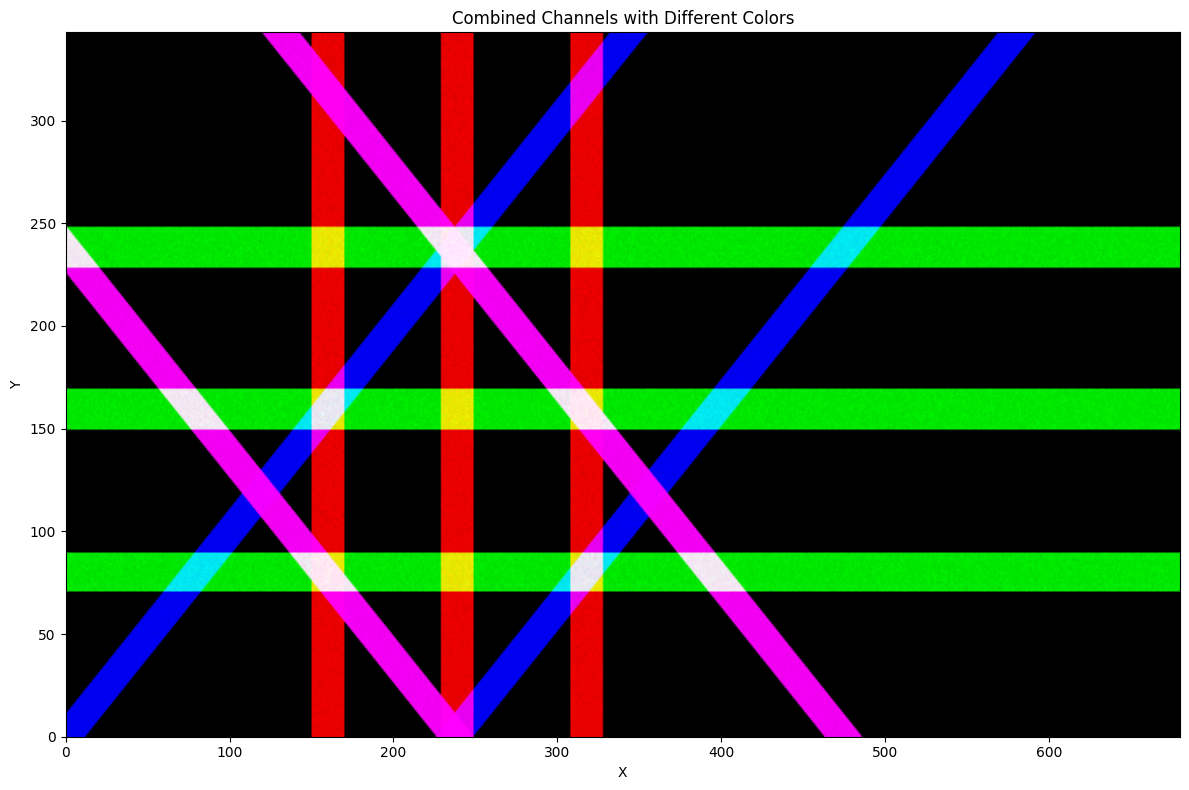


✓ Combined channels visualization (RGB)
  RGB image shape: (344, 681, 3)
  Per-channel image shape: (4, 344, 681)


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Load data: shape (channel, value, z, y, x)
data = np.load('groundtruth.npy')
n_channels, n_values, n_z, y_dim, x_dim = data.shape

# Predefine an RGB color for each channel (R, G, B)
channel_colors = np.array([
    [1.0, 0.0, 0.0],  # Channel 0: red
    [0.0, 1.0, 0.0],  # Channel 1: green
    [0.0, 0.0, 1.0],  # Channel 2: blue
    [1.0, 0.0, 1.0],  # Channel 3: magenta
], dtype=np.float32)

# Store the 2D projection per channel
per_channel_2d = np.zeros((n_channels, y_dim, x_dim), dtype=np.float32)

for channel in range(n_channels):
    channel_data = data[channel]  # Shape: (value, z, y, x) = (11, 12, 87, 172)

    # value indices: 0..(n_values-1)
    value_indices = np.arange(n_values).reshape(-1, 1, 1, 1)  # (value, 1, 1, 1)

    # Weighted sum over "value" axis
    weighted_sum = np.sum(value_indices * channel_data, axis=0)  # (z, y, x)
    total_sum = np.sum(channel_data, axis=0)                     # (z, y, x)

    avg_value_index = np.where(total_sum > 0, weighted_sum / total_sum, 0)  # (z, y, x)

    # Average over z to get a 2D image for this channel
    avg_z = np.mean(avg_value_index, axis=0)  # (y, x)

    per_channel_2d[channel] = avg_z

# Build an RGB image from all channels
combined_rgb = np.zeros((y_dim, x_dim, 3), dtype=np.float32)

for channel in range(n_channels):
    img = per_channel_2d[channel]

    # Skip empty channels
    if np.all(img == 0):
        continue

    # Normalize this channel's image to [0, 1] for visualization
    img_min = img.min()
    img_max = img.max()
    norm = (img - img_min) / (img_max - img_min + 1e-6)

    # Add this channel's contribution in its own color
    color = channel_colors[channel]  # (3,)
    combined_rgb += norm[..., None] * color  # broadcast to (y, x, 3)

# Clip to valid [0, 1] RGB range
combined_rgb = np.clip(combined_rgb, 0.0, 1.0)

# Plot combined RGB image
plt.figure(figsize=(12, 8))
plt.imshow(
    combined_rgb,
    origin='lower',
    extent=[0, x_dim - 1, 0, y_dim - 1],
    aspect='auto',
    interpolation='bilinear'
)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Combined Channels with Different Colors')
plt.xlim(0, x_dim - 1)
plt.ylim(0, y_dim - 1)
plt.tight_layout()
plt.show()

print("\n✓ Combined channels visualization (RGB)")
print(f"  RGB image shape: {combined_rgb.shape}")
print(f"  Per-channel image shape: {per_channel_2d.shape}")


In [4]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio


pio.renderers.default = "browser"
# Load data: shape (channel, value, z, y, x)
data = np.load("groundtruth_colonies.npy")
n_channels, n_values, n_z, y_dim, x_dim = data.shape

# Colors per channel
channel_colors = [
    "red",      # channel 0
    "green",    # channel 1
    "blue",     # channel 2
    "magenta",  # channel 3
]

# Compute a 3D scalar field per channel: avg over "value"
per_channel_3d = np.zeros((n_channels, n_z, y_dim, x_dim), dtype=np.float32)

for ch in range(n_channels):
    channel_data = data[ch]

    value_indices = np.arange(n_values, dtype=np.float32).reshape(-1, 1, 1, 1)
    weighted_sum = np.sum(value_indices * channel_data, axis=0)
    total_sum = np.sum(channel_data, axis=0)

    avg_value_index = np.zeros_like(weighted_sum)
    mask = total_sum > 0
    avg_value_index[mask] = weighted_sum[mask] / total_sum[mask]

    per_channel_3d[ch] = avg_value_index


# --- Plotly 3D scatter ---
fig = go.Figure()
threshold = 0.5
max_points = 10000

for ch in range(n_channels):
    vol = per_channel_3d[ch]

    if np.all(vol == 0):
        continue

    vmin, vmax = vol.min(), vol.max()
    if vmax <= vmin:
        continue

    norm = (vol - vmin) / (vmax - vmin + 1e-6)
    mask = norm > threshold

    if not np.any(mask):
        continue

    z_idx, y_idx, x_idx = np.where(mask)

    # limit number of points
    n_pts = len(x_idx)
    if n_pts > max_points:
        selected = np.random.choice(n_pts, max_points, replace=False)
        x_idx = x_idx[selected]
        y_idx = y_idx[selected]
        z_idx = z_idx[selected]

    fig.add_trace(go.Scatter3d(
        x=x_idx,
        y=y_idx,
        z=z_idx,
        mode="markers",
        marker=dict(
            size=2,
            color=channel_colors[ch],
            opacity=0.8  # must be single number!
        ),
        name=f"Biomarker {ch}"
    ))


fig.update_layout(
    title="3D Interactive View of Channels",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode="data",
    ),
    autosize=True,
    showlegend=True,
)

fig.show(config={
    'displayModeBar': True,
    'displaylogo': False,
    'modeBarButtonsToAdd': ['toImage'],
    'toImageButtonOptions': {
        'format': 'png',
        'filename': '3d_visualization',
        'height': None,
        'width': None,
        'scale': 1
    }
})


In [3]:
import numpy as np

# Define dimensions (same as before)
num_channels = 4
value_range = (0, 10)
z_range = (0, 48)
y_range = (0, 343)
x_range = (0, 680)

num_values = value_range[1] - value_range[0] + 1
z_dim = z_range[1] - z_range[0] + 1
y_dim = y_range[1] - y_range[0] + 1
x_dim = x_range[1] - x_range[0] + 1

# Calculate scaling factors
x_scale = x_dim / 172
y_scale = y_dim / 87

# Create 5D array initialized with zeros
data = np.zeros((num_channels, num_values, z_dim, y_dim, x_dim), dtype=np.int8)

# Parameters for random colonies
max_radius = 50
num_colonies_per_line = 8  # Number of colony centers per line

def create_random_cloud(center_x, center_y, center_z, radius, z_dim, y_dim, x_dim):
    """Create a random cloud of points around a center with random shape"""
    # Generate random number of points in the cloud (between 20 to 100)
    num_points = np.random.randint(20, 101)
    
    # Create random shape: mix of sphere and ellipsoid
    shape_type = np.random.choice(['sphere', 'ellipsoid', 'elongated'])
    
    points = []
    for _ in range(num_points):
        if shape_type == 'sphere':
            # Uniform sphere distribution
            theta = np.random.uniform(0, 2 * np.pi)
            phi = np.random.uniform(0, np.pi)
            r = np.random.uniform(0, radius) ** (1/3)  # Cube root for uniform volume distribution
            dx = r * np.sin(phi) * np.cos(theta)
            dy = r * np.sin(phi) * np.sin(theta)
            dz = r * np.cos(phi)
        elif shape_type == 'ellipsoid':
            # Random ellipsoid with different axes
            axes = np.random.uniform(0.3, 1.0, 3) * radius
            theta = np.random.uniform(0, 2 * np.pi)
            phi = np.random.uniform(0, np.pi)
            r = np.random.uniform(0, 1) ** (1/3)
            dx = r * axes[0] * np.sin(phi) * np.cos(theta)
            dy = r * axes[1] * np.sin(phi) * np.sin(theta)
            dz = r * axes[2] * np.cos(phi)
        else:  # elongated
            # Elongated shape along random direction
            direction = np.random.uniform(-1, 1, 3)
            direction = direction / np.linalg.norm(direction)
            r_parallel = np.random.uniform(0, radius)
            r_perp = np.random.uniform(0, radius * 0.4)
            perp1 = np.cross(direction, [1, 0, 0])
            if np.linalg.norm(perp1) < 0.1:
                perp1 = np.cross(direction, [0, 1, 0])
            perp1 = perp1 / np.linalg.norm(perp1)
            perp2 = np.cross(direction, perp1)
            perp2 = perp2 / np.linalg.norm(perp2)
            
            angle = np.random.uniform(0, 2 * np.pi)
            offset = r_parallel * direction + r_perp * (np.cos(angle) * perp1 + np.sin(angle) * perp2)
            dx, dy, dz = offset[0], offset[1], offset[2]
        
        x = int(center_x + dx)
        y = int(center_y + dy)
        z = int(center_z + dz)
        
        # Check bounds
        if 0 <= x < x_dim and 0 <= y < y_dim and 0 <= z < z_dim:
            points.append((x, y, z))
    
    return points

# Channel 0: 3D Arc from (0,0,0) to (x_max, y_max, z_max) - create once for all z
# 3D Arc from origin to maximum coordinates
num_arc_points = num_colonies_per_line * 3

# Parameter t goes from 0 to 1
t_values = np.linspace(0, 1, num_arc_points)

# Arc with elevation: create a smooth arc that curves upward/downward
# Using a sinusoidal elevation to create arc shape
arc_amplitude = 0.3  # How much the arc curves (as fraction of dimensions)

for t in t_values:
    # Base linear interpolation from (0,0,0) to (x_max, y_max, z_max)
    x_arc_base = t * (x_dim - 1)
    y_arc_base = t * (y_dim - 1)
    z_arc_base = t * (z_dim - 1)
    
    # Add arc curvature: sinusoidal elevation in y and z
    # The arc curves in a plane, creating a smooth arc shape
    angle = t * np.pi  # From 0 to π
    arc_elevation_y = arc_amplitude * (y_dim - 1) * np.sin(angle)
    arc_elevation_z = arc_amplitude * (z_dim - 1) * np.sin(angle)
    
    # Final arc position
    x_arc = x_arc_base
    y_arc = y_arc_base + arc_elevation_y
    z_arc = z_arc_base + arc_elevation_z
    
    # Ensure within bounds
    x_arc = int(np.clip(x_arc, 0, x_dim - 1))
    y_arc = int(np.clip(y_arc, 0, y_dim - 1))
    z_arc = int(np.clip(z_arc, 0, z_dim - 1))
    
    # Create colony at this arc point in 3D space
    radius = np.random.uniform(10, max_radius)
    cloud_points = create_random_cloud(x_arc, y_arc, z_arc, radius, z_dim, y_dim, x_dim)
    
    # Set points for all positions in the cloud
    for x, y, z_val in cloud_points:
        if 0 <= x < x_dim and 0 <= y < y_dim and 0 <= z_val < z_dim:
            random_value = np.random.randint(6, 11)
            data[0, random_value, z_val, y, x] = 1

# Generate data with random colony clouds instead of linear stripes
for i in range(0, 3):
    for z in range(z_dim):
        # Channel 0: Second curved vertical line (concave) - only for i=1
        if i == 1:
            # Keep the original concave vertical curve for i=1
            x_base = int((38 + 20 * i) * x_scale)
            y_center = y_dim / 2  # Center of the curve
            
            # Inverse convex (concave) curve: x = x_base - amplitude * (1 - 4*((y - y_center)/y_range)^2)
            # This creates an elliptical curve bulging inward
            amplitude_curve = 120  # Doubled
            
            # Create colony centers along the curved line
            colony_y_positions = np.linspace(0, y_dim - 1, num_colonies_per_line * 2)  # More points for smooth curve
            
            for colony_y in colony_y_positions:
                # Calculate x position on the curve
                y_normalized = (colony_y - y_center) / (y_dim / 2)  # Normalize to [-1, 1]
                y_normalized = np.clip(y_normalized, -1, 1)
                
                # Elliptical curve: 1 - y_normalized^2 creates a smooth oval shape
                curve_offset = amplitude_curve * (1 - y_normalized**2)
                
                # Concave inward (inverse convex)
                curve_x = x_base - curve_offset
                
                # Add small random offset perpendicular to curve
                # For vertical curves, perpendicular offset is horizontal
                center_x = int(curve_x + np.random.uniform(-8, 8))
                center_y = int(colony_y + np.random.uniform(-5, 5))
                center_x = int(np.clip(center_x, 0, x_dim - 1))
                center_y = int(np.clip(center_y, 0, y_dim - 1))
                
                radius = np.random.uniform(10, max_radius)
                cloud_points = create_random_cloud(center_x, center_y, z, radius, z_dim, y_dim, x_dim)
                for x, y, z_val in cloud_points:
                    if z_val == z:  # Only set points in current z slice
                        random_value = np.random.randint(6, 11)
                        data[0, random_value, z, y, x] = 1
        
        # Channel 1: Semi-sinusoidal horizontal line - colonies on peaks
        # Sinusoidal pattern: y = y_base + amplitude * sin(frequency * x + phase)
        # Peak should be at y = 300
        y_base = int((18 + 20 * i) * y_scale)
        target_peak_y = 150
        
        # Calculate amplitude so that peak reaches target_peak_y
        # Peak = y_base + amplitude, so amplitude = target_peak_y - y_base
        amplitude = max(50, min(target_peak_y - y_base, y_dim - y_base - 50))  # Ensure reasonable amplitude
        frequency = 2 * np.pi / (x_dim / 3)  # 3 cycles across width
        phase = i * np.pi / 2  # Different phase for each i
        
        # Find peaks of sinusoidal function
        # Peaks occur when sin(frequency * x + phase) = 1, i.e., when frequency * x + phase = π/2 + 2πk
        # x = (π/2 + 2πk - phase) / frequency
        x_samples = []
        k_range = int(x_dim * frequency / (2 * np.pi)) + 1
        for k in range(-1, k_range + 1):
            peak_x = (np.pi / 2 + 2 * np.pi * k - phase) / frequency
            if 0 <= peak_x < x_dim:
                x_samples.append(peak_x)
        
        # Limit number of colonies (doubled for sinusoidal)
        if len(x_samples) > num_colonies_per_line * 4:
            # Select evenly spaced peaks (double the number)
            indices = np.linspace(0, len(x_samples) - 1, num_colonies_per_line * 2, dtype=int)
            x_samples = [x_samples[idx] for idx in indices]
        
        # Create colonies at peak positions
        for x_sample in x_samples:
            # Calculate y at peak (y = y_base + amplitude)
            peak_y = y_base + amplitude
            
            # Add small random offset
            center_x = int(x_sample + np.random.uniform(-8, 8))
            center_y = int(peak_y + np.random.uniform(-5, 5))
            center_x = int(np.clip(center_x, 0, x_dim - 1))
            center_y = int(np.clip(center_y, 0, y_dim - 1))
            
            radius = np.random.uniform(10, max_radius)
            cloud_points = create_random_cloud(center_x, center_y, z, radius, z_dim, y_dim, x_dim)
            for x, y, z_val in cloud_points:
                if z_val == z:
                    random_value = np.random.randint(6, 11)
                    data[1, random_value, z, y, x] = 1
        
        # Channel 2: Semi-sinusoidal diagonal line (y = x + c + sin) - colonies on peaks
        c_values = [int(-60 * x_scale), 0]
        for c in c_values:
            # Sinusoidal diagonal: y = x + c + amplitude * sin(frequency * x + phase)
            target_peak_y = 150
            diagonal_base = c
            # Adjust amplitude so peak reaches target_peak_y
            amplitude_sin = max(30, min(100, (target_peak_y - diagonal_base) / 2))
            frequency_sin = 2 * np.pi / (x_dim / 4)  # 4 cycles
            phase_sin = i * np.pi / 3
            
            # Find peaks: derivative = 1 + amplitude * frequency * cos(freq*x + phase) = 0
            # cos(freq*x + phase) = -1/(amplitude * frequency)
            # This gives us x positions near peaks
            x_range_valid = range(max(0, -c), min(x_dim, y_dim - c))
            if len(x_range_valid) == 0:
                continue
            
            # Sample points along diagonal and find peaks (doubled for sinusoidal)
            x_samples_diag = np.linspace(x_range_valid.start, x_range_valid.stop - 1, 
                                         num_colonies_per_line * 8)
            peak_positions = []
            prev_y = None
            for idx in range(1, len(x_samples_diag) - 1):
                x_prev = x_samples_diag[idx - 1]
                x_curr = x_samples_diag[idx]
                x_next = x_samples_diag[idx + 1]
                
                y_prev = x_prev + c + amplitude_sin * np.sin(frequency_sin * x_prev + phase_sin)
                y_curr = x_curr + c + amplitude_sin * np.sin(frequency_sin * x_curr + phase_sin)
                y_next = x_next + c + amplitude_sin * np.sin(frequency_sin * x_next + phase_sin)
                
                # Check if this is a peak (local maximum)
                if y_curr > y_prev and y_curr > y_next and 0 <= y_curr < y_dim:
                    peak_positions.append((x_curr, y_curr))
            
            # Select evenly spaced peaks (doubled for sinusoidal)
            if len(peak_positions) > num_colonies_per_line * 2:
                indices = np.linspace(0, len(peak_positions) - 1, num_colonies_per_line * 2, dtype=int)
                peak_positions = [peak_positions[idx] for idx in indices]
            
            # Create colonies at peak positions
            for x_peak, y_peak in peak_positions:
                # Add random offset perpendicular to curve
                perp_offset = np.random.uniform(-12, 12)
                center_x = int(x_peak + perp_offset / np.sqrt(2))
                center_y = int(y_peak - perp_offset / np.sqrt(2))
                center_x = int(np.clip(center_x, 0, x_dim - 1))
                center_y = int(np.clip(center_y, 0, y_dim - 1))
                
                radius = np.random.uniform(10, max_radius)
                cloud_points = create_random_cloud(center_x, center_y, z, radius, z_dim, y_dim, x_dim)
                for x, y, z_val in cloud_points:
                    if z_val == z:
                        random_value = np.random.randint(6, 11)
                        data[2, random_value, z, y, x] = 1
        
        # Channel 3: Diagonal lines with slope -1 (y = -x + d) - convert to random colonies
        d_values = [int(60 * y_scale), int(120 * y_scale)]
        for d in d_values:
            # Create colony centers along diagonal line
            x_samples = np.linspace(max(0, d - y_dim + 1), min(x_dim - 1, d), num_colonies_per_line)
            for x_sample in x_samples:
                if x_sample < 0 or x_sample >= x_dim:
                    continue
                y_line = -x_sample + d
                if y_line < 0 or y_line >= y_dim:
                    continue
                
                # Add random offset perpendicular to line
                perp_offset = np.random.uniform(-15, 15)
                center_x = int(x_sample + perp_offset / np.sqrt(2))
                center_y = int(y_line + perp_offset / np.sqrt(2))
                center_x = int(np.clip(center_x, 0, x_dim - 1))
                center_y = int(np.clip(center_y, 0, y_dim - 1))
                
                radius = np.random.uniform(10, max_radius)
                cloud_points = create_random_cloud(center_x, center_y, z, radius, z_dim, y_dim, x_dim)
                for x, y, z_val in cloud_points:
                    if z_val == z:
                        random_value = np.random.randint(6, 11)
                        data[3, random_value, z, y, x] = 1

print(f"Created 5D data array with random colony clouds: {data.shape}")
print(f"Dimensions breakdown:")
print(f"  - Channels: {num_channels} (1, 2, 3, 4)")
print(f"  - Values: {num_values} (0 to {value_range[1]})")
print(f"  - Z: {z_dim} (0 to {z_range[1]})")
print(f"  - Y: {y_dim} (0 to {y_range[1]})")
print(f"  - X: {x_dim} (0 to {x_range[1]})")
print(f"\nRandom colony parameters:")
print(f"  - Max radius: {max_radius}")
print(f"  - Colonies per line: {num_colonies_per_line}")
print(f"  - Cloud shapes: sphere, ellipsoid, elongated")
print(f"  - Channel 0: 3D Arc from (0,0,0) to (x_max,y_max,z_max) and one concave vertical curve")
print(f"  - Sinusoidal lines: Channel 1 (horizontal), Channel 2 (diagonal)")
print(f"  - Sinusoidal peak target: y = 300")
print(f"\nData type: {data.dtype}")
print(f"Total elements: {data.size:,}")
print(f"Memory size: {data.nbytes / 1024 / 1024:.2f} MB")

# Save the data
np.save('groundtruth_colonies.npy', data)
print(f"\n✓ 5D data with random colonies saved to: groundtruth_colonies.npy")


Created 5D data array with random colony clouds: (4, 11, 49, 344, 681)
Dimensions breakdown:
  - Channels: 4 (1, 2, 3, 4)
  - Values: 11 (0 to 10)
  - Z: 49 (0 to 48)
  - Y: 344 (0 to 343)
  - X: 681 (0 to 680)

Random colony parameters:
  - Max radius: 50
  - Colonies per line: 8
  - Cloud shapes: sphere, ellipsoid, elongated
  - Channel 0: 3D Arc from (0,0,0) to (x_max,y_max,z_max) and one concave vertical curve
  - Sinusoidal lines: Channel 1 (horizontal), Channel 2 (diagonal)
  - Sinusoidal peak target: y = 300

Data type: int8
Total elements: 505,073,184
Memory size: 481.68 MB

✓ 5D data with random colonies saved to: groundtruth_colonies.npy


#Create graphs and subgraphs